<a href="https://colab.research.google.com/github/suryamadhab-m/brain-tumer-mri-classification/blob/main/Brain_Tumor_MRI_Classification_Colab_Suryamadhab_Moharana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -q kaggle grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 81.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
import os, time, json
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from google.colab import files
uploaded = files.upload()  # upload your kaggle.json here

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d brain_mri_data


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 216MB/s]



In [5]:
IMG_SIZE = 150
BATCH_SIZE = 32
TRAIN_DIR = "brain_mri_data/Training"
TEST_DIR  = "brain_mri_data/Testing"

train_full = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode="categorical", seed=42, validation_split=0.15, subset="training"
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode="categorical", seed=42, validation_split=0.15, subset="validation"
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode="categorical", shuffle=False
)

CLASS_NAMES = train_full.class_names
print("Classes:", CLASS_NAMES)

# Normalization + augmentation (applied only to training data)
normalization = layers.Rescaling(1./255)
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomBrightness(0.1),
])

def prep_train(x, y):
    x = augmentation(x)
    x = normalization(x)
    return x, y

def prep_eval(x, y):
    return normalization(x), y

train_ds = train_full.map(prep_train).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.map(prep_eval).prefetch(tf.data.AUTOTUNE)
test_ds_raw = test_ds  # keep raw (unnormalized) version for Grad-CAM visualization later
test_ds  = test_ds.map(prep_eval).prefetch(tf.data.AUTOTUNE)

Found 5600 files belonging to 4 classes.
Using 4760 files for training.
Found 5600 files belonging to 4 classes.
Using 840 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
def build_lightweight_cnn(input_shape=(150, 150, 3), num_classes=4):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Depthwise-separable blocks = far fewer parameters than standard Conv2D
    for filters in [64, 128, 128]:
        x = layers.SeparableConv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu", name="last_conv")(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="lightweight_brain_tumor_cnn")

model = build_lightweight_cnn(num_classes=len(CLASS_NAMES))
model.summary()

total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")  # report this number in your paper

Model: "lightweight_brain_tumor_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 75, 75, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 37, 37, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 18, 18, 128)    │        17,664 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv (Conv2D)              │ (None, 9, 9, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           26

 Total params: 187,364 (731.89 KB)

 Trainable params: 186,660 (729.14 KB)

 Non-trainable params: 704 (2.75 KB)


Total parameters: 187,364


Epoch 1/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 54s 244ms/step - accuracy: 0.6092 - loss: 0.9603 - val_accuracy: 0.2452 - val_loss: 1.6064 - learning_rate: 0.0010
Epoch 2/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.7366 - loss: 0.6822 - val_accuracy: 0.2536 - val_loss: 2.1865 - learning_rate: 0.0010
Epoch 3/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 137ms/step - accuracy: 0.7870 - loss: 0.5535 - val_accuracy: 0.4048 - val_loss: 2.6413 - learning_rate: 0.0010
Epoch 4/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 19s 127ms/step - accuracy: 0.8221 - loss: 0.4723 - val_accuracy: 0.7202 - val_loss: 0.6999 - learning_rate: 0.0010
Epoch 5/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 138ms/step - accuracy: 0.8380 - loss: 0.4327 - val_accuracy: 0.7274 - val_loss: 0.9296 - learning_rate: 0.0010
Epoch 6/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 139ms/step - accuracy: 0.8532 - loss: 0.3962 - val_accuracy: 0.8512 - val_loss: 0.3862 - learning_rate: 0.0010
Epoch 7/30
149/149 ━━━━━━━━━━━━━━━━━━━━ 19s 127ms/step - accuracy: 0.8

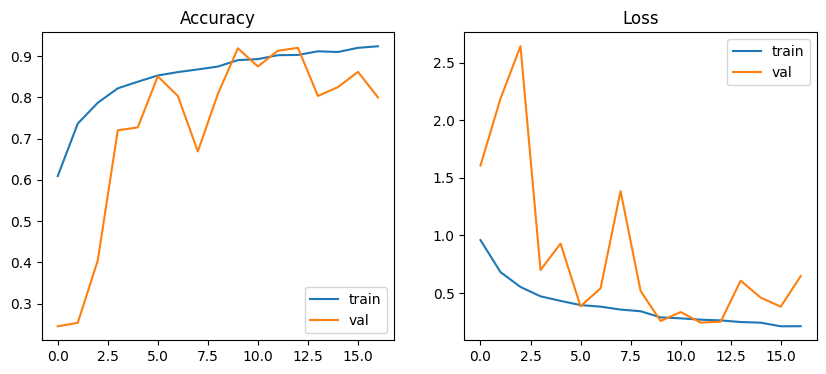

In [7]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks
)

# Plot training curves -- include these plots in your paper
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.legend()
plt.savefig("training_curves.png", dpi=150)
plt.show()

              precision    recall  f1-score   support

      glioma     1.0000    0.5850    0.7382       400
  meningioma     0.7731    0.7750    0.7740       400
     notumor     0.8305    0.9925    0.9043       400
   pituitary     0.8111    0.9875    0.8906       400

    accuracy                         0.8350      1600
   macro avg     0.8537    0.8350    0.8268      1600
weighted avg     0.8537    0.8350    0.8268      1600

Macro F1: 0.8267933600525419


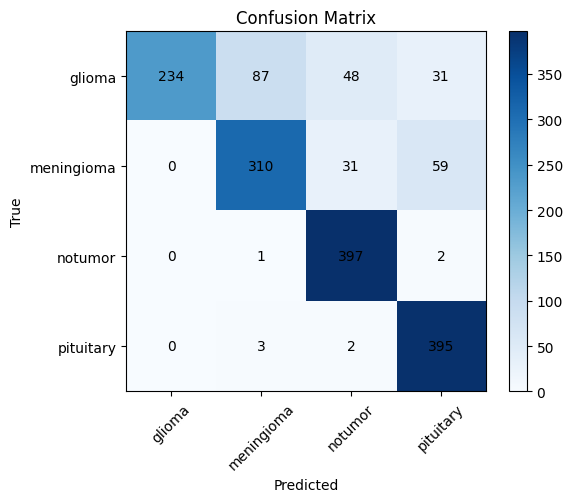

In [8]:
y_true, y_pred = [], []
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print("Macro F1:", f1_score(y_true, y_pred, average="macro"))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=45)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.colorbar()
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


In [10]:
# %% CELL 7 - CPU inference time benchmark
import time as _time

# Save and reload model to ensure CPU compatibility
model.save("lightweight_brain_tumor_cnn.h5")

# Load fresh on CPU
with tf.device('/CPU:0'):
    cpu_model = tf.keras.models.load_model("lightweight_brain_tumor_cnn.h5")
    sample_batch = next(iter(test_ds.take(1)))[0][:1]

    # warm-up
    _ = cpu_model.predict(sample_batch, verbose=0)

    start = _time.time()
    N = 50
    for _ in range(N):
        _ = cpu_model.predict(sample_batch, verbose=0)
    elapsed = (_time.time() - start) / N

print(f"Average CPU inference time per image: {elapsed*1000:.2f} ms")

Average CPU inference time per image: 139.03 ms


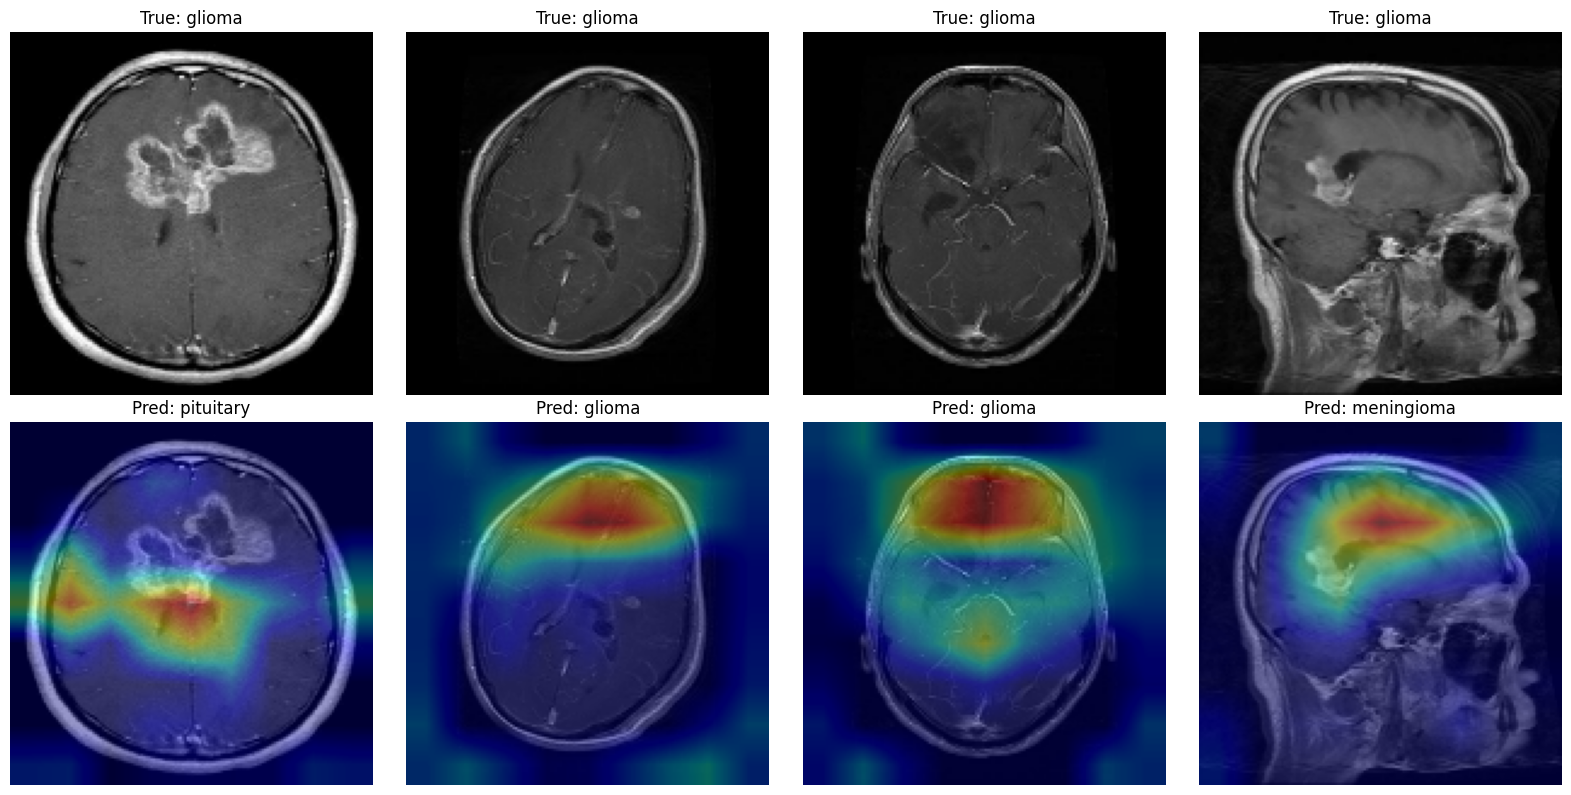

In [12]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="last_conv"):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), CLASS_NAMES[pred_index.numpy()]

# Visualize Grad-CAM on a few sample test images
import matplotlib.cm as cm

raw_images, raw_labels = next(iter(test_ds_raw.take(1)))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img = raw_images[i].numpy().astype("uint8")
    img_norm = normalization(tf.expand_dims(raw_images[i], 0))
    heatmap, pred_class = make_gradcam_heatmap(img_norm, model)

    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], (IMG_SIZE, IMG_SIZE)).numpy().squeeze()
    heatmap_colored = cm.jet(heatmap_resized)[..., :3] * 255
    overlay = (0.6 * img + 0.4 * heatmap_colored).astype("uint8")

    true_class = CLASS_NAMES[np.argmax(raw_labels[i].numpy())]

    axes[0, i].imshow(img); axes[0, i].set_title(f"True: {true_class}"); axes[0, i].axis("off")
    axes[1, i].imshow(overlay); axes[1, i].set_title(f"Pred: {pred_class}"); axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("gradcam_samples.png", dpi=150)
plt.show()

# >>> Include gradcam_samples.png in your paper's Results section as
# >>> qualitative evidence the model attends to clinically relevant regions


In [13]:
model.save("lightweight_brain_tumor_cnn.h5")

results_summary = {
    "total_parameters": int(total_params),
    "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
    "avg_cpu_inference_ms": float(elapsed * 1000),
    "class_names": CLASS_NAMES,
}
with open("results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=2)

print(json.dumps(results_summary, indent=2))
files.download("results_summary.json")
files.download("training_curves.png")
files.download("confusion_matrix.png")
files.download("gradcam_samples.png")

{
  "total_parameters": 187364,
  "macro_f1": 0.8267933600525419,
  "avg_cpu_inference_ms": 139.03228759765625,
  "class_names": [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
  ]
}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>